## Simulating an ordinary differential equation with SciPy
Rozwiązania układu Lotki-Volterry $\frac{dx}{dt}=(a-by)x$, $\frac{dy}{dt}=(cx-d)y$


Rozwiązanie układu Logistic-Growth $\frac{dt}{dx}=a_1x+a_2xy+a_3x^2$ ,$\frac{dt}{dy}=b_1y+b_2xy+b_3y^2$


Wykorzystując metodę Eulera rozwiąż numerycznie autonomiczny układ równań różniczkowych zwyczajnych typu Lotki-Volterry. Szkielet propozycji rozwiązania znajduje się w dołączonyn do zadania notebooku Lab.I.100.raw.ipynb. Rozwiązanie numeryczne układu autonomicznego
 $y′ = f (y)$ polega na próbkowaniu czasu krokiem dt i zastąpieniu $y′(t)$ ilorazem $\frac{y(t+dt)−y(t)}{dt}$ oraz warunkiem początkowym $y0 = y(t0)$, a następnie iteracją $y_{n+1} =y_{n} +dt·f(y_n)$.

In [18]:
import numpy as np
import scipy.integrate as spi
from scipy.integrate import solve_ivp
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
def lotkaV(t, z, a1=5.0, a2=0.2, a3=0.005, b1=1.0 ,b2=0.03, b3=0.01):
    x,y = z
    return [a1*x - a2*y*x - a3*x*x , - b1*y + b2*x*y - b3*y*y]

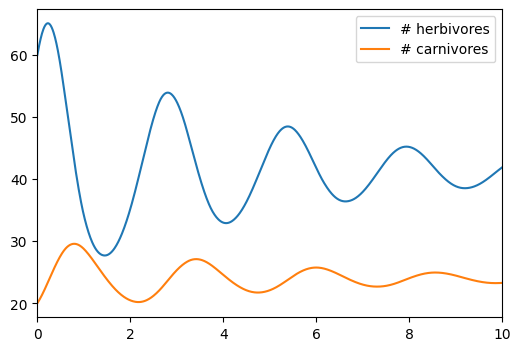

In [25]:
sol = solve_ivp(lotkaV, [0,10], [60,20], dense_output=True)
t = np.arange(0,10,0.01)
z = sol.sol(t)
# plt.plot(t, z.T)
# plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(t, z[0], label=f'# herbivores')
ax.plot(t, z[1], label=f'# carnivores')
ax.legend()
ax.set_xlim(0, 10)
plt.show()

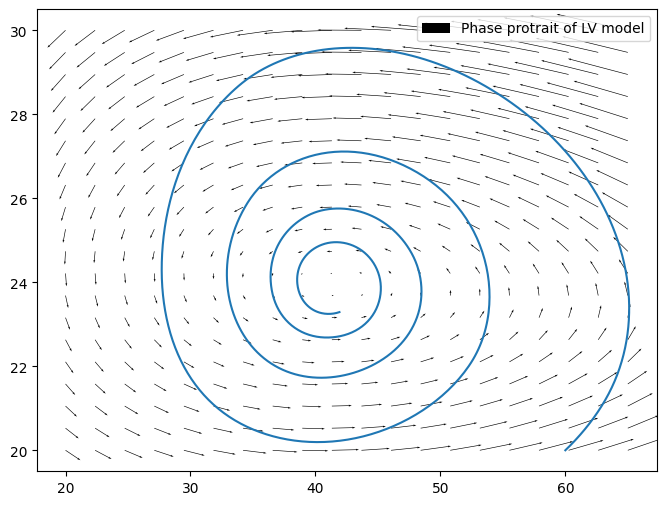

In [21]:
from scipy.integrate import odeint, solve_ivp

def vfield(t, point):
    #dx/dt = 5x -0.005x^2 - 0.2xy
    #dy/dt = -y -0.01y^2 + 0.03xy
    x = point[0]
    y = point[1]
    new_x = x * (5 - 0.005 * x - 0.2 * y)
    new_y = y * (-1 + 0.03 * x - 0.01 * y)
    return [new_x, new_y]

def vfield2(t, point):
     #dx/dt = 5x -0.005x^2 - 0.2xy
    #dy/dt = -y -0.01y^2 + 0.03xy
    # x = point[0]
    # y = point[1]
    # new_x = x * (5 - 0.005 * x - 0.2 * y)
    # new_y = y * (-1 + 0.03 * x - 0.01 * y)
    # return [new_x, new_y]

he = np.linspace(20,65,20)  #start, stop, num
ca = np.linspace(20,30,20)  #start, stop, num
he,ca = np.meshgrid(he,ca)

dhe,dca=vfield(0, (he,ca))

t=np.linspace(0,10,1000)
sol=solve_ivp(fun=vfield, t_span=[0,10], y0=[60,20], t_eval=t) #solve_ivp(fun, t_span, y0, method='RK45')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.quiver(he,ca,dhe,dca,width=0.001,scale=750)
ax.legend(["Phase protrait of LV model"])
ax.plot(sol.y[0], sol.y[1], label="Trajectory")
plt.show()


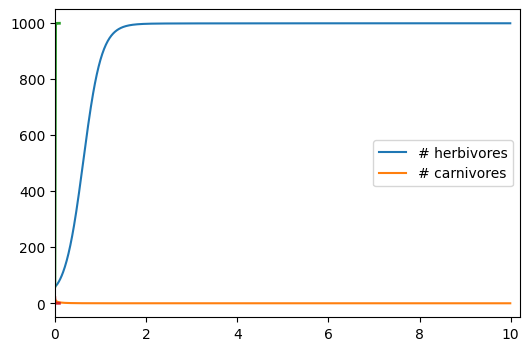

In [22]:
dt = 0.01 # time step
T = 10 # total time
n = int(T/dt) # number of time steps

# x = np.zeros(n)
# y = np.zeros(n)
#
# x[0] = 60
# y[0] = 20

x = [60]
y = [20]

def LV_Euler(x, y, n, dt):

    for i in range(n-1):
        fx, fy = lotkaV(i,z=(x[i],y[i]))
        x_next = x[i] + fx * dt
        y_next = y[i] + fy * dt
        x.append(x_next)
        y.append(y_next)

    return np.array(x), np.array(y)


x,y = LV_Euler(x, y, n, dt)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(x, label=f'# herbivores')
ax.plot(y, label=f'# carnivores')
ax.legend()
ax.set_xlim(0, 1020)
ticks = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x*1/100))
ax.xaxis.set_major_formatter(ticks)


plt.plot(t, x, lw=2, label=f'roslin')
plt.plot(t, y, lw=2, label=f'mięso')